# Exercise 4.A Introduction to Linear Regression

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Lab 1

### Running a sample script

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [5]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [7]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [8]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


# Scatter plot: actual test data points

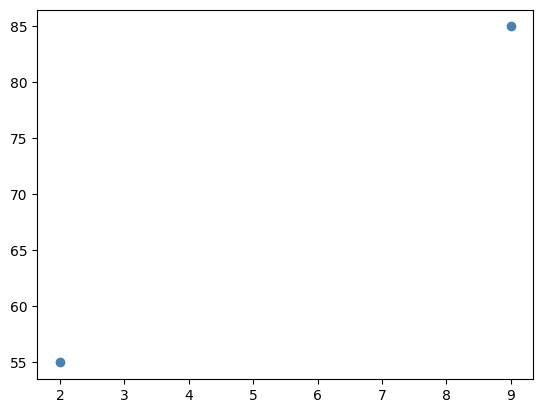

In [12]:
plt.scatter(X_test, y_test, color='steelblue', label='Actual',zorder=3)

# Line: model predictions across the full range of X

/Users/fb.baslar/Desktop/YearupProjects/week-06/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


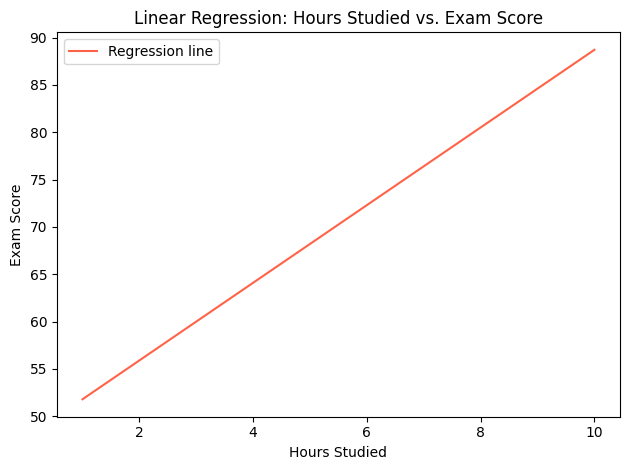

In [14]:
x_range = np.linspace(
 X['hours_studied'].min(),
 X['hours_studied'].max(),
 100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

## Lab 2

### Building your own model

In [20]:
ad_data = {
 'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
 'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}
df_ads = pd.DataFrame(ad_data)

In [21]:
X2 = df_ads[['monthly_ad_spend']]

In [22]:
y2 = df_ads['monthly_revenue']

In [24]:
print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

X2 shape: (20, 1)
y2 shape: (20,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [26]:
model2 = LinearRegression()

In [30]:
model2.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [31]:
print(f'Slope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')

Slope (coefficient): 1.96
Intercept: 3625.89


In [32]:
y_pred = model2.predict(X_test)

In [33]:
print(f"{'Actual Value':<15} | {'Predicted Value':<15}")
for actual, predicted in zip(y_test, y_pred):
    print(f"{actual:<15.2f} | {predicted:<15.2f}")

Actual Value    | Predicted Value
4200.00         | 4603.85        
21500.00        | 21229.03       
19400.00        | 19273.13       
5100.00         | 5581.80        


In [34]:
r_squared = model2.score(X_test, y_test)
print(f'R-squared score: {r_squared:.3f}')

R-squared score: 0.998


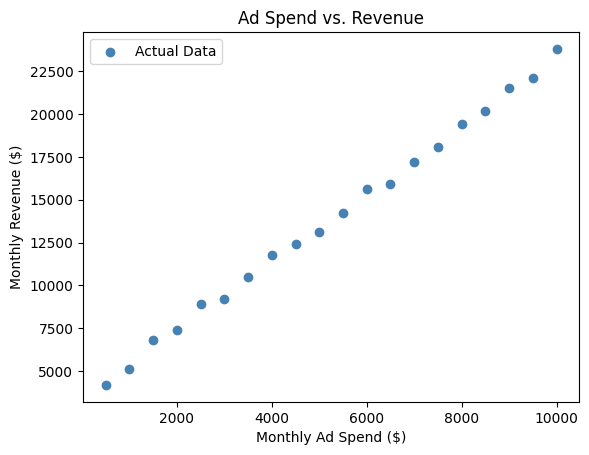

In [35]:
# 20. Scatter plot of the full dataset
plt.scatter(X2, y2, color='steelblue', label='Actual Data')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.show()

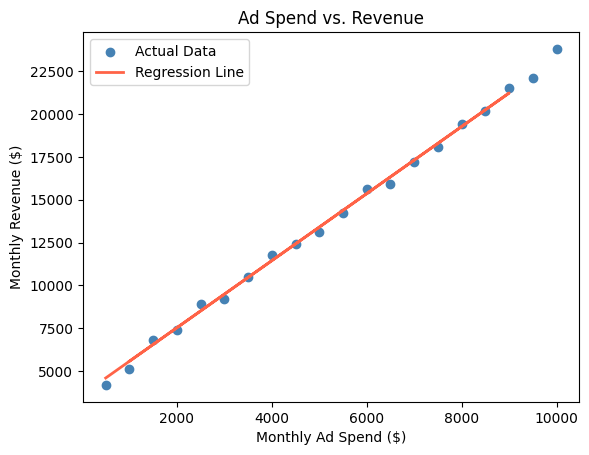

In [36]:
# 21. Scatter plot with regression line overlay
plt.scatter(X2, y2, color='steelblue', label='Actual Data')
plt.plot(X_test, y_pred, color='tomato', label='Regression Line', linewidth=2)
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.show()

In [37]:
# Visual Fit: The regression line provides a clear linear trend for the data points. While some points show variation, the line captures the overall positive relationship between ad spend and revenue.

In [39]:
# R-squared Interpretation: The visual fit aligns well with the R score calculated in the previous step. A high R value confirms that a significant portion of the variance in monthly revenue is explained by the monthly ad spend